In [31]:
import pandas as pd

In [32]:
import numpy as np

In [33]:
import matplotlib.pyplot as mlb

In [34]:
df= pd.read_excel('planilha_modulo3.xlsx')

In [35]:
lista_idades = [26,30,32,22,26,35,400,20,43,31,23]

In [36]:
media= np.mean(lista_idades)
print("A média das idades é: ", media)

A média das idades é:  62.54545454545455


In [37]:
desvio= np.std(lista_idades)
print("O desvio padrão das idades é: ", desvio)

O desvio padrão das idades é:  106.89532997398872


In [38]:
media + 3*desvio

np.float64(383.2314444674207)

{'whiskers': [<matplotlib.lines.Line2D at 0x10cccb8e0>,
 'caps': [<matplotlib.lines.Line2D at 0x10cccb880>,
 'boxes': [<matplotlib.lines.Line2D at 0x10ce1d100>],
 'medians': [<matplotlib.lines.Line2D at 0x10cccb550>],
 'fliers': [<matplotlib.lines.Line2D at 0x10cd7da60>],
 'means': []}

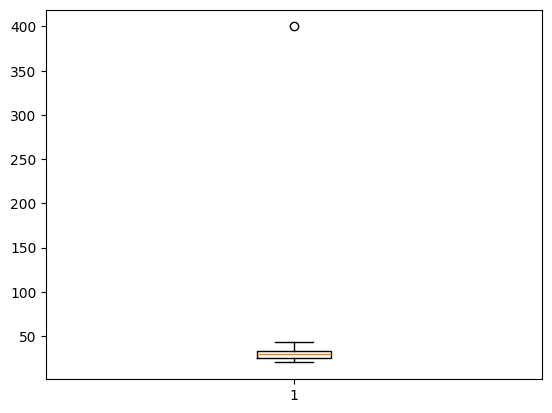

In [39]:
mlb.boxplot(lista_idades)

In [41]:
df.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'NIVEL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO'],
      dtype='object')

{'whiskers': [<matplotlib.lines.Line2D at 0x10cdce610>,
 'caps': [<matplotlib.lines.Line2D at 0x10cdceb50>,
 'boxes': [<matplotlib.lines.Line2D at 0x10cdce370>],
 'medians': [<matplotlib.lines.Line2D at 0x10c8950d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x10c895370>],
 'means': []}

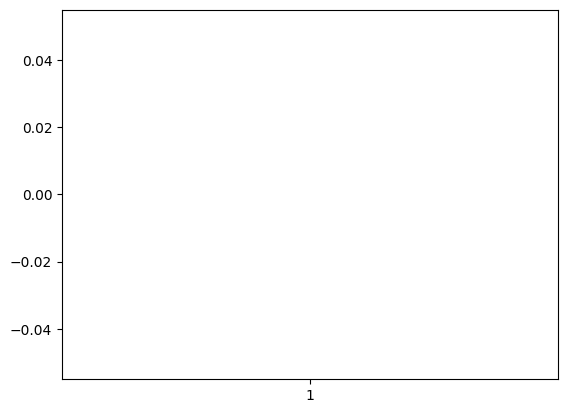

In [43]:
mlb.boxplot(df['SALARIO'])

In [47]:
Q1 = df['SALARIO'].quantile(0.25)
Q1

np.float64(4269.5)

In [48]:
Q3 = df['SALARIO'].quantile(0.75)
Q3

np.float64(12778.5)

In [49]:
QR = Q3 - Q1
QR

np.float64(8509.0)

In [50]:
lim_superior = Q3 + 1.5 * QR
lim_superior

np.float64(25542.0)

In [52]:
lim_inferior = Q1 - 1.5 * QR
lim_inferior

np.float64(-8494.0)

In [55]:
df['FAIXA SALARIAL'].value_counts()

FAIXA SALARIAL
de R$ 8.001/mês a R$ 12.000/mês     752
de R$ 4.001/mês a R$ 6.000/mês      584
de R$ 6.001/mês a R$ 8.000/mês      527
de R$ 12.001/mês a R$ 16.000/mês    437
de R$ 3.001/mês a R$ 4.000/mês      303
de R$ 2.001/mês a R$ 3.000/mês      285
de R$ 16.001/mês a R$ 20.000/mês    229
de R$ 1.001/mês a R$ 2.000/mês      216
de R$ 20.001/mês a R$ 25.000/mês    134
de R$ 25.001/mês a R$ 30.000/mês     77
de R$ 30.001/mês a R$ 40.000/mês     70
Acima de R$ 40.001/mês               45
Menos de R$ 1.000/mês                35
Name: count, dtype: int64

In [57]:
mediasal = df['SALARIO'].mean()
mediasal

np.float64(10969.26691932864)

In [58]:
desviosal = df['SALARIO'].std()
desviosal

np.float64(19419.75318876344)

In [62]:
lim_superior = mediasal + 3 * desviosal
lim_superior

np.float64(69228.52648561896)

In [63]:
df[df['SALARIO']>lim_superior]['FAIXA SALARIAL'].value_counts()

FAIXA SALARIAL
Acima de R$ 40.001/mês              15
de R$ 30.001/mês a R$ 40.000/mês     3
Name: count, dtype: int64

In [71]:
media_30_40 = df[
    (df['FAIXA SALARIAL'] == 'de R$ 30.001/mês a R$ 40.000/mês') &
    (df['SALARIO'] < lim_superior)
]['SALARIO'].mean()

media_30_40

np.float64(39002.19402985075)

In [72]:
df.loc[
    (df['FAIXA SALARIAL'] == 'de R$ 30.001/mês a R$ 40.000/mês') &
    (df['SALARIO'] > lim_superior),
    'SALARIO'
] = media_30_40

In [73]:
df[df['SALARIO'] > lim_superior]['FAIXA SALARIAL'].value_counts()

FAIXA SALARIAL
Acima de R$ 40.001/mês    15
Name: count, dtype: int64

In [74]:
media_40 = df[
    (df['FAIXA SALARIAL'] == 'Acima de R$ 40.001/mês') &
    (df['SALARIO'] < lim_superior)
]['SALARIO'].mean()

media_40

np.float64(54999.03333333333)

In [76]:
df.loc[
    (df['FAIXA SALARIAL'] == 'Acima de R$ 40.001/mês') &
    (df['SALARIO'] > lim_superior),
    'SALARIO'
] = media_40

In [78]:
df[df['SALARIO'] > lim_superior]['FAIXA SALARIAL'].value_counts()

Series([], Name: count, dtype: int64)

{'whiskers': [<matplotlib.lines.Line2D at 0x10d06c1f0>,
 'caps': [<matplotlib.lines.Line2D at 0x10d06c730>,
 'boxes': [<matplotlib.lines.Line2D at 0x10d063f40>],
 'medians': [<matplotlib.lines.Line2D at 0x10d06cc70>],
 'fliers': [<matplotlib.lines.Line2D at 0x10d06cf10>],
 'means': []}

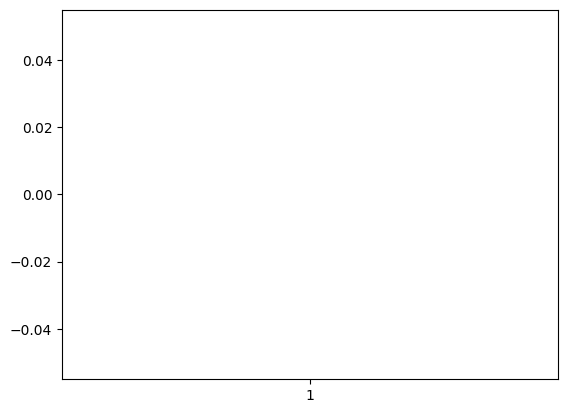

In [80]:
mlb.boxplot(df['SALARIO'])